# Unión de los dos datasets

In [ ]:
import pandas as pd
import nltk

# Descarga de recursos necesarios
nltk.download('stopwords')
nltk.download('punkt')

# ============================================================
# 1️⃣ Dataset inglés (HASOC 2019)
# ============================================================
print("Cargando dataset inglés...")
df_eng = pd.read_csv("english_dataset.csv", sep=";", encoding="utf-8", on_bad_lines="skip", engine="python")

# Eliminar columnas vacías
df_eng = df_eng.loc[:, ~df_eng.columns.str.contains('^Unnamed')]
df_eng.columns = [c.strip().replace("﻿", "") for c in df_eng.columns]

# Si existen columnas con los nombres esperados
if "text_id" in df_eng.columns and "text" in df_eng.columns:
    df_eng = df_eng[["text_id", "text"]].rename(columns={"text_id": "ID", "text": "text"})
else:
    # Si no, tomamos las dos primeras columnas como ID y texto
    df_eng = df_eng.iloc[:, :2]
    df_eng.columns = ["ID", "text"]

df_eng["lang"] = "eng"
print(f"✅ Dataset inglés cargado: {df_eng.shape}")
print(df_eng.head(), "\n")

# ============================================================
# 2️⃣ Dataset español (toxic_test)
# ============================================================
print("Cargando dataset español...")
df_spa = pd.read_csv("toxic_test.csv", encoding="latin-1", on_bad_lines="skip")

# Si viene en formato 'id;text', lo dividimos
if df_spa.columns[0] == "id;text":
    df_spa = df_spa["id;text"].str.split(";", n=1, expand=True)
    df_spa.columns = ["ID", "text"]

df_spa["lang"] = "spa"
print(f"✅ Dataset español cargado: {df_spa.shape}")
print(df_spa.head(), "\n")

# ============================================================
# 3️⃣ UNIÓN Y LIMPIEZA FINAL
# ============================================================
print("Uniendo datasets...")
df = pd.concat([df_eng, df_spa], ignore_index=True)
df.dropna(subset=["text"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Dataset combinado correctamente: {df.shape}")
print(df.sample(5))

# ============================================================
# 4️⃣ GUARDAR RESULTADO
# ============================================================
df.to_csv("Merged_Dataset.csv", index=False, encoding="utf-8")
print("\n💾 Archivo guardado como 'Merged_Dataset.csv'")


Cargando dataset inglés...
✅ Dataset inglés cargado: (5852, 3)
           ID                                               text lang
0  hasoc_en_1  #DhoniKeepsTheGlove | WATCH: Sports Minister K...  eng
1  hasoc_en_2  @politico No. We should remember very clearly ...  eng
2  hasoc_en_3  @cricketworldcup Guess who would be the winner...  eng
3  hasoc_en_4  Corbyn is too politically intellectual for #Bo...  eng
4  hasoc_en_5  All the best to #TeamIndia for another swimmin...  eng 

Cargando dataset español...
✅ Dataset español cargado: (1154, 3)
      ID                                               text lang
0  20929  Esto es para ti indocumentado  https://t.co/8m...  spa
1  22807  @CameArrascae Cllate perra que deje la ventana...  spa
2  24595  @A_Bermejo Han echo de puta madre en ensearte ...  spa
3  23092  @realDonaldTrump recuerde seor presidente el x...  spa
4  22129             heeeeeey gero  https://t.co/UFcgGli3th  spa 

Uniendo datasets...
✅ Dataset combinado correctamente: (70

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Etiquetado artificial y limpieza de datos

In [ ]:
import pandas as pd
import numpy as np
import re
import unicodedata
import csv

# ===============================
# 1️⃣ Cargar dataset original
# ===============================
df = pd.read_csv("Merged_Dataset.csv", encoding="utf-8", engine="python")

# ===============================
# 2️⃣ Normalización de texto
# ===============================
def normalize(text):
    text = str(text).strip().lower()
    text = "".join(ch for ch in unicodedata.normalize("NFKD", text)
                   if not unicodedata.combining(ch))
    text = re.sub(r"\s+", " ", text)
    return text

df["text"] = df["text"].astype(str)
df["_norm"] = df["text"].apply(normalize)

# ===============================
# 3️⃣ Léxicos
# ===============================
POLITICAL = ["democrat","republican","trump","biden","gobierno","izquierda","derecha"]
RACIAL = ["black","white","latino","immigrant","negro","blanco"]
RELIGIOUS = ["christian","muslim","islam","cristiano","musulman"]
GENDER = ["woman","man","trans","lgbt","mujer","hombre"]

VILIFICATION = ["trash","idiot","stupid","basura","idiota"]
EXTREME = ["kill","die","death","matar","morir"]

def contains_any(text, lexicon):
    for w in lexicon:
        if re.search(rf"\b{re.escape(w)}\b", text):
            return True
    return False

# ===============================
# 4️⃣ Etiquetado limpio
# ===============================
def label_row(txt):
    pol = contains_any(txt, POLITICAL)
    rac = contains_any(txt, RACIAL)
    rel = contains_any(txt, RELIGIOUS)
    gen = contains_any(txt, GENDER)
    vil = contains_any(txt, VILIFICATION)
    ext = contains_any(txt, EXTREME)

    polarized = any([pol, rac, rel, gen, vil, ext])

    return pd.Series({
        "political": int(pol),
        "racial/ethnic": int(rac),
        "religious": int(rel),
        "gender/sexual": int(gen),
        "vilification": int(vil),
        "dehumanization": 0,
        "extreme_language": int(ext),
        "lack_of_empathy": 0,
        "stereotype": 0,
        "invalidation": 0,
        "other": 0,
        "polarization": int(polarized)
    })

labels = df["_norm"].apply(label_row)

df_final = pd.concat([df[["text","lang","ID"]], labels], axis=1)

# ===============================
# 5️⃣ Limpieza final
# ===============================
df_final = df_final[df_final["lang"].isin(["eng","spa"])]
df_final = df_final.dropna(subset=["text"])
df_final = df_final.drop_duplicates(subset=["text"]).reset_index(drop=True)

# ===============================
# 6️⃣ Guardar CORRECTAMENTE
# ===============================
df_final.to_csv(
    "Unified_Dataset_Clean_Final.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL
)

print("✅ Dataset regenerado correctamente")
print("Shape:", df_final.shape)
print("\nDistribución polarización:")
print(df_final["polarization"].value_counts())

✅ Dataset regenerado correctamente
Shape: (6966, 15)

Distribución polarización:
polarization
0    5978
1     988
Name: count, dtype: int64


# Análisis Exploratorio

In [ ]:
!pip install textstat
!python -m spacy download es_core_news_sm
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 118.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 123.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ============================================================
#  ANÁLISIS TEXTOMÉTRICO Y DE COMPLEJIDAD LÉXICA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import textstat

# ------------------------------------------------------------
#  Descarga de recursos
# ------------------------------------------------------------
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# ============================================================
#  CARGA DEL DATASET
# ============================================================
df = pd.read_csv("Unified_Dataset_Clean_Final.csv")
print(" Datos cargados:", df.shape)
display(df.head())
print("\nDistribución de idiomas:")
print(df["lang"].value_counts())

# ============================================================
#  CONFIGURACIÓN DE STOPWORDS
# ============================================================
stopwords_es = stopwords.words('spanish')
stopwords_en = stopwords.words('english')

# ============================================================
#  FRECUENCIA LÉXICA (TEXTOMETRÍA)
# ============================================================

# --- Español ---
vectorizer_es = CountVectorizer(stop_words=stopwords_es, max_features=5000)
X_es = vectorizer_es.fit_transform(df.loc[df["lang"]=="spa", "text"].astype(str))
freq_es = np.sum(X_es, axis=0)
freq_dist_es = dict(zip(vectorizer_es.get_feature_names_out(), freq_es.A1))

# --- Inglés ---
vectorizer_en = CountVectorizer(stop_words=stopwords_en, max_features=5000)
X_en = vectorizer_en.fit_transform(df.loc[df["lang"]=="eng", "text"].astype(str))
freq_en = np.sum(X_en, axis=0)
freq_dist_en = dict(zip(vectorizer_en.get_feature_names_out(), freq_en.A1))

print("\n Top palabras en español:", sorted(freq_dist_es.items(), key=lambda x: x[1], reverse=True)[:20])
print("\n Top palabras en inglés:", sorted(freq_dist_en.items(), key=lambda x: x[1], reverse=True)[:20])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


 Datos cargados: (6966, 15)


,text,lang,ID,political,racial/ethnic,religious,gender/sexual,vilification,dehumanization,extreme_language,lack_of_empathy,stereotype,invalidation,other,polarization
0,#DhoniKeepsTheGlove | WATCH: Sports Minister K...,eng,hasoc_en_1,0,0,0,0,0,0,0,0,0,0,0,0
1,@politico No. We should remember very clearly ...,eng,hasoc_en_2,0,0,0,0,0,0,0,0,0,0,0,0
2,@cricketworldcup Guess who would be the winner...,eng,hasoc_en_3,0,0,0,0,0,0,0,0,0,0,0,0
3,Corbyn is too politically intellectual for #Bo...,eng,hasoc_en_4,0,0,0,0,0,0,0,0,0,0,0,0
4,All the best to #TeamIndia for another swimmin...,eng,hasoc_en_5,0,0,0,0,0,0,0,0,0,0,0,0



Distribución de idiomas:
lang
eng    5817
spa    1149
Name: count, dtype: int64

 Top palabras en español: [('puta', np.int64(386)), ('co', np.int64(363)), ('https', np.int64(354)), ('perra', np.int64(161)), ('callate', np.int64(138)), ('cllate', np.int64(120)), ('hijo', np.int64(81)), ('zorra', np.int64(81)), ('si', np.int64(76)), ('ms', np.int64(63)), ('madre', np.int64(62)), ('mereces', np.int64(58)), ('polla', np.int64(51)), ('mierda', np.int64(49)), ('mujer', np.int64(48)), ('ser', np.int64(45)), ('acoso', np.int64(43)), ('cara', np.int64(40)), ('arabe', np.int64(36)), ('rabe', np.int64(36))]

 Top palabras en inglés: [('https', np.int64(2666)), ('co', np.int64(2663)), ('fucktrump', np.int64(1051)), ('icc', np.int64(805)), ('trumpisatraitor', np.int64(757)), ('realdonaldtrump', np.int64(722)), ('trump', np.int64(643)), ('doctorsfightback', np.int64(607)), ('shameonicc', np.int64(568)), ('dhonikeepstheglove', np.int64(516)), ('doctors', np.int64(384)), ('borisjohnsonshouldnotbepm'

# Visualizaciones

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


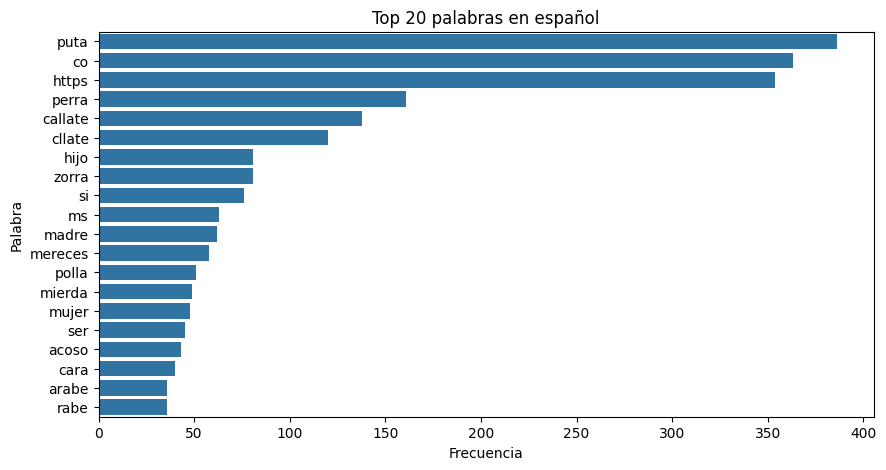

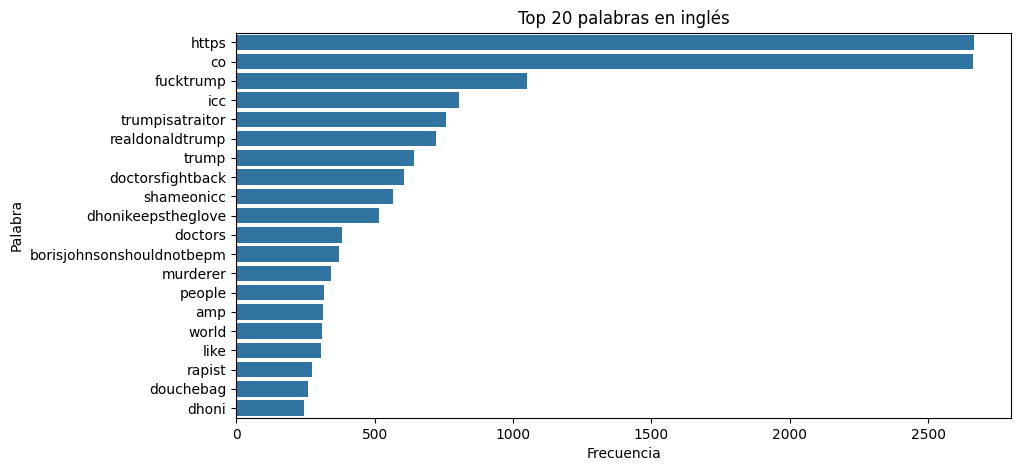

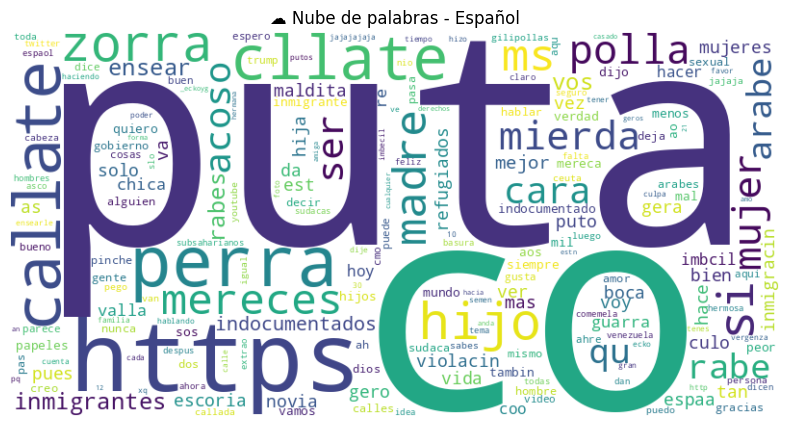

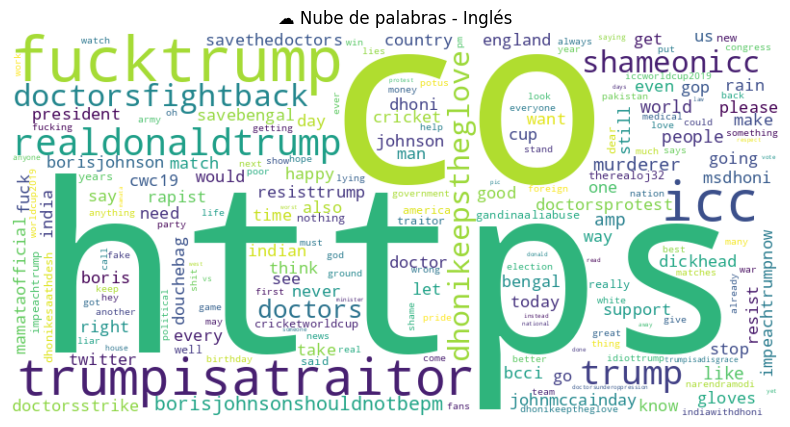

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# --- Descarga de recursos (if not already done) ---
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# --- Carga del dataset (needed to define 'df') ---
df = pd.read_csv("Unified_Dataset_Clean_Final.csv")

# --- Configuración de Stopwords ---
stopwords_es = stopwords.words('spanish')
stopwords_en = stopwords.words('english')

# --- Frecuencia Léxica (Textometría) - Copied from previous cell to define variables ---
# --- Español ---
vectorizer_es = CountVectorizer(stop_words=stopwords_es, max_features=5000)
X_es = vectorizer_es.fit_transform(df.loc[df["lang"]=="spa", "text"].astype(str))
freq_es = np.sum(X_es, axis=0)
freq_dist_es = dict(zip(vectorizer_es.get_feature_names_out(), freq_es.A1))

# --- Inglés ---
vectorizer_en = CountVectorizer(stop_words=stopwords_en, max_features=5000)
X_en = vectorizer_en.fit_transform(df.loc[df["lang"]=="eng", "text"].astype(str))
freq_en = np.sum(X_en, axis=0)
freq_dist_en = dict(zip(vectorizer_en.get_feature_names_out(), freq_en.A1))

# ============================================================
# VISUALIZACIONES
# ============================================================

def plot_top_words(freq_dict, title):
    top_words = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)[:20]
    words, counts = zip(*top_words)
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(title)
    plt.xlabel("Frecuencia")
    plt.ylabel("Palabra")
    plt.show()

plot_top_words(freq_dist_es, "Top 20 palabras en español")
plot_top_words(freq_dist_en, "Top 20 palabras en inglés")

# --- Nube de palabras ---
def wordcloud_from_freq(freq_dict, title):
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freq_dict)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

wordcloud_from_freq(freq_dist_es, "☁️ Nube de palabras - Español")
wordcloud_from_freq(freq_dist_en, "☁️ Nube de palabras - Inglés")

# Métricas Léxicas y Complejidad

In [ ]:
# ============================================================
# MÉTRICAS LÉXICAS Y COMPLEJIDAD
# ============================================================

def lexical_diversity(texts):
    tokens = [word.lower() for text in texts for word in nltk.word_tokenize(text) if word.isalpha()]
    return len(set(tokens)) / len(tokens) if tokens else 0

def avg_sentence_length(texts):
    sentences = [nltk.sent_tokenize(text) for text in texts]
    lengths = [len(nltk.word_tokenize(s)) for sub in sentences for s in sub]
    return np.mean(lengths) if lengths else 0

# Filtrar por idioma
texts_es = df.loc[df["lang"]=="spa", "text"].astype(str).tolist()
texts_en = df.loc[df["lang"]=="eng", "text"].astype(str).tolist()

# Métricas léxicas básicas
print("\n---  Métricas Léxicas Básicas ---")
print("Diversidad léxica (español):", lexical_diversity(texts_es))
print("Diversidad léxica (inglés):", lexical_diversity(texts_en))
print("Longitud promedio de oraciones (español):", avg_sentence_length(texts_es))
print("Longitud promedio de oraciones (inglés):", avg_sentence_length(texts_en))


---  Métricas Léxicas Básicas ---
Diversidad léxica (español): 0.2728645383951682
Diversidad léxica (inglés): 0.1200619736852668
Longitud promedio de oraciones (español): 13.18688901667625
Longitud promedio de oraciones (inglés): 13.73134211351521


# Comparación

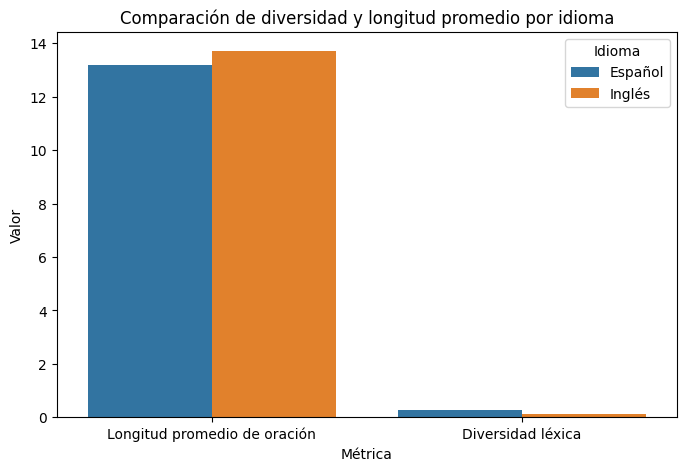

In [ ]:
# ============================================================
# VISUALIZACIÓN COMPARATIVA DE COMPLEJIDAD
# ============================================================

def compare_complexity(texts_es, texts_en):
    data = {
        "Idioma": ["Español", "Inglés"],
        "Longitud promedio de oración": [avg_sentence_length(texts_es), avg_sentence_length(texts_en)],
        "Diversidad léxica": [lexical_diversity(texts_es), lexical_diversity(texts_en)]
    }
    df_comp = pd.DataFrame(data).melt(id_vars="Idioma", var_name="Métrica", value_name="Valor")

    plt.figure(figsize=(8,5))
    sns.barplot(x="Métrica", y="Valor", hue="Idioma", data=df_comp)
    plt.title("Comparación de diversidad y longitud promedio por idioma")
    plt.show()

compare_complexity(texts_es, texts_en)

# Complejidad Textual

In [ ]:
# ============================================================
# COMPLEJIDAD TEXTUAL AVANZADA (Textstat)
# ============================================================

def text_complexity(texts, lang):
    scores = {
        "Flesch Reading Ease": [],
        "Flesch-Kincaid Grade": [],
        "Dale-Chall": [],
        "Coleman-Liau": [],
        "SMOG Index": []
    }
    for t in texts:
        try:
            scores["Flesch Reading Ease"].append(textstat.flesch_reading_ease(t))
            scores["Flesch-Kincaid Grade"].append(textstat.flesch_kincaid_grade(t))
            scores["Dale-Chall"].append(textstat.dale_chall_readability_score(t))
            scores["Coleman-Liau"].append(textstat.coleman_liau_index(t))
            scores["SMOG Index"].append(textstat.smog_index(t))
        except:
            continue
    df_scores = pd.DataFrame(scores)
    print(f"\n Promedios de complejidad textual - {lang.upper()}:")
    print(df_scores.mean())

text_complexity(texts_es, "español")
text_complexity(texts_en, "inglés")


 Promedios de complejidad textual - ESPAÑOL:
Flesch Reading Ease     45.124450
Flesch-Kincaid Grade    10.119185
Dale-Chall              19.071042
Coleman-Liau            11.440511
SMOG Index              10.155122
dtype: float64

 Promedios de complejidad textual - INGLÉS:
Flesch Reading Ease     36.455182
Flesch-Kincaid Grade    11.253750
Dale-Chall              12.158471
Coleman-Liau            18.597462
SMOG Index              11.677680
dtype: float64


# Análisis morfológico


🔍 Distribución morfológica - Español
   Categoría  Proporción
6       NOUN    0.189807
4      PROPN    0.135229
2        ADP    0.128662
3       VERB    0.122619
5        DET    0.116971
0       PRON    0.076120
7        ADJ    0.074938
1        AUX    0.039603
8        ADV    0.038093
9      CCONJ    0.037633
11     SCONJ    0.036254
13       NUM    0.002758
12      INTJ    0.000657
10     PUNCT    0.000328
14      PART    0.000197
15         X    0.000066
16       SYM    0.000066


/tmp/ipython-input-1428612985.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Proporción", y="Categoría", data=pos_df, palette="viridis")


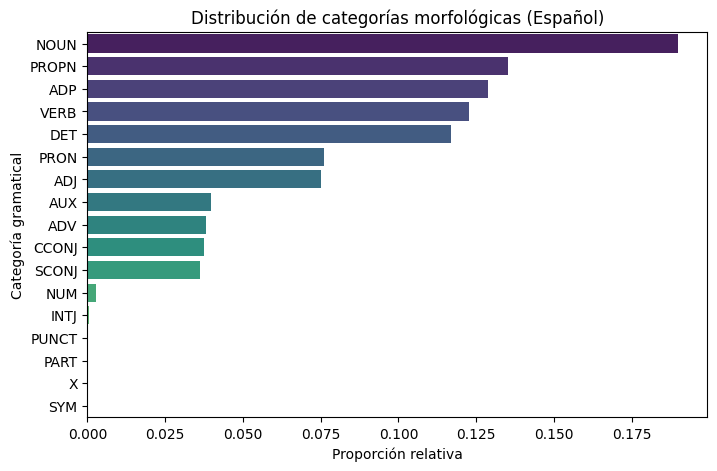


🔍 Distribución morfológica - Inglés
   Categoría  Proporción
3       NOUN    0.223649
1      PROPN    0.162526
2       VERB    0.130094
10      PRON    0.093503
4        ADP    0.091684
6        DET    0.067256
8        AUX    0.059148
13       ADJ    0.054834
11       ADV    0.039397
5       PART    0.022505
7      CCONJ    0.020946
12     SCONJ    0.018711
0        NUM    0.006133
9       INTJ    0.005873
14         X    0.002651
15     PUNCT    0.001091


/tmp/ipython-input-1428612985.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Proporción", y="Categoría", data=pos_df, palette="viridis")


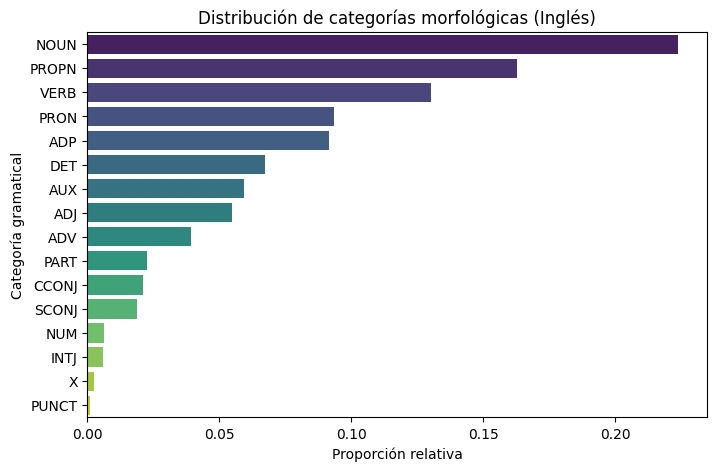

In [ ]:
# ============================================================
#  ANÁLISIS MORFOLÓGICO (Part-of-Speech tagging)
# ============================================================

import spacy
from collections import Counter

# Cargar modelos para español e inglés
nlp_es = spacy.load("es_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")

# Filtrar textos por idioma
texts_es = df.loc[df["lang"] == "spa", "text"].astype(str).tolist()
texts_en = df.loc[df["lang"] == "eng", "text"].astype(str).tolist()

def morph_analysis(texts, nlp_model, lang_name):
    """
    Función para analizar la morfología de una lista de textos.
    Retorna la proporción de tipos de palabras por categoría gramatical.
    """
    pos_counts = Counter()
    total_tokens = 0

    for text in texts[:1000]:  # Limita a 1000 textos para eficiencia
        doc = nlp_model(text)
        pos_counts.update([token.pos_ for token in doc if token.is_alpha])
        total_tokens += len([token for token in doc if token.is_alpha])

    pos_freq = {pos: count / total_tokens for pos, count in pos_counts.items()}
    pos_df = pd.DataFrame(pos_freq.items(), columns=["Categoría", "Proporción"])
    pos_df = pos_df.sort_values(by="Proporción", ascending=False)

    print(f"\n🔍 Distribución morfológica - {lang_name}")
    print(pos_df)

    # Visualización
    plt.figure(figsize=(8,5))
    sns.barplot(x="Proporción", y="Categoría", data=pos_df, palette="viridis")
    plt.title(f"Distribución de categorías morfológicas ({lang_name})")
    plt.xlabel("Proporción relativa")
    plt.ylabel("Categoría gramatical")
    plt.show()

    return pos_df

# Ejecutar análisis morfológico
morph_es = morph_analysis(texts_es, nlp_es, "Español")
morph_en = morph_analysis(texts_en, nlp_en, "Inglés")